
<html>
<body>




<p align="center">
<img src="https://cdn-04.9rayti.com/rsrc/cache/widen_292/uploads/2012/07/ensias.png" alt="logo ensias" width="120" height="140"/></p>

<p align="center"><b><font size="5">Tutorial: Régression linéaire simple </font></b></p>
<p align="center"><b><font size="5" color="gray">(Méthode des moindres carrés) </font></b></p>


---


<br>
<font size="2">
<b>Élément de module :</b>	Deep learning<br>	
<b>Année universitaire :</b>	2019-2020<br>
<b>Semestre :</b>	
</font>		


---

<font size="2">
<I>Pr. Aissam BERRAHOU</I></font>
<br>
<br>


</body>
</html>


<font size="2">
La régression a pour objectif d’expliquer une variable Y par une autre variable X. Par exemple on peut expliquer les performances d’un athlète par la durée de son entrainement ou même  le salaire d’une personne par le nombre d’années passées à l’université. Dans notre cas on s’intéresse à la régression linéaire multiple qui modélise la relation entre X(ensembles de variables explicatives) et Y par une équation linéaire.
</font>

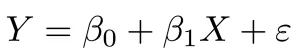


**Traitements réalisés** :<br>
<font size="2">
* Création d'une base de données
* Splitting de la base de données
* Visualisation de la base de donnée
* Choix de modèle (Linèaire)
* Recherche des paramètres du modèle(appliquer la méthode des moindres carrés)
* Evaluation du modèle par la méthode d'analyse de la variance(Ensemble de test)
</font>


# <font color="red" size="4"><b>1. Création d'une base de données</font>


In [1]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt


In [2]:
n_observations=50
x,y=make_regression(n_samples=n_observations,n_features=1, noise=10)
y=y.reshape(n_observations,1)
print(np.shape(x))
print(y.shape)

(50, 1)
(50, 1)


 <font color="blue" size="3">a. Spiliting de la base de données en deux sous-ensembles(Apprentissage et Test)</font>

In [3]:
from sklearn.model_selection import train_test_split
x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

 <font color="blue" size="3">b. Visualisation des deux sous-ensembles(Apprentissage et Test)</font>

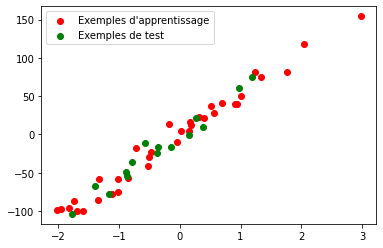

In [4]:
plt.scatter(x_train,y_train, c='r',label="Exemples d'apprentissage")
plt.scatter(x_test,y_test, c='green',label='Exemples de test')
plt.legend()

# <font color="red" size="4"><b>2. Choix de modèle</font>


image.png


<font color="blue" size="3">a. Spécification des élements du modèle</font>

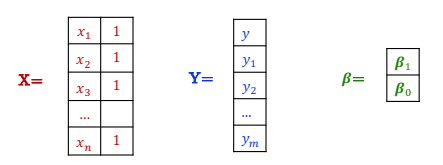

In [5]:
n=np.shape(x_train)[0]
vecteur_unitaire=np.ones((n,1))

X_tr=np.hstack((x_train,vecteur_unitaire))

beta=np.zeros((2,1))

print(X_tr.shape)
print(beta.shape)

(35, 2)
(2, 1)


In [6]:
def modele(X,beta):
  return X.dot(beta)

<font color="blue" size="3">b. Visualisation des données avec le modèle de régression avant l'apprentissage</font>

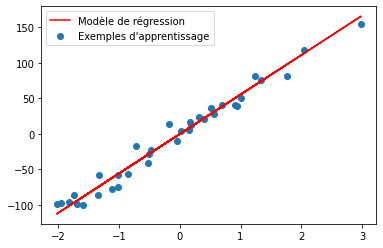

In [14]:
y_pred=modele(X_tr,beta)
plt.scatter(x_train,y_train,label="Exemples d'apprentissage")
plt.plot(x_train,y_pred,c='r',label="Modèle de régression")
plt.legend()

# <font color="red" size="4"><b>3. Recherche des paramètres du modèle(en utilisant la méthode des moindres carrés)</font>


## <font color="blue" size="3">a.Méthode 1: Sans notation matricielle</font>
<div style="max-width:400px; margin-right: 0;">

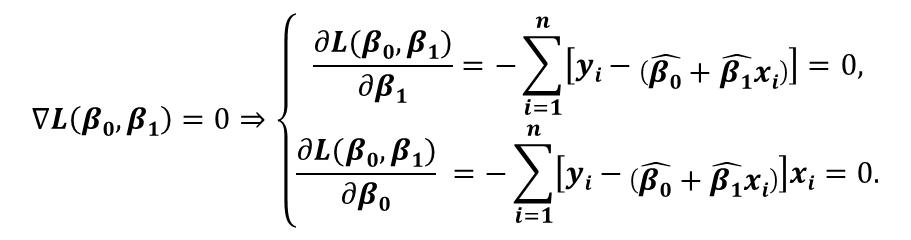



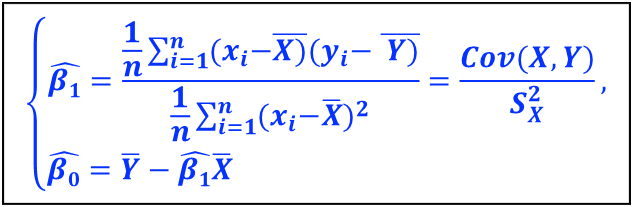 

</div>

In [179]:
#calcul de la covaraince de X et Y
N=len(y_train)
X_m = np.mean(x_train)
Y_m = np.mean(y_train)

x_X=x_train-X_m
y_Y=y_train-Y_m

Z=x_X [:,0]* y_Y[:,0]

covxy= np.sum(Z) / N
print(covxy)


79.8044584836982


In [183]:
#calcul de la varaince de X 
varx=np.sum((x_X**2)[:],axis=0)/N

In [185]:
beta=np.zeros((2,1))
beta[0,0]=covxy/varx
beta[1,0]=np.mean(y_train[:,0],axis=0)-np.mean(x_train[:,0],axis=0)*beta[0,0]

In [186]:
beta

array([[53.94844202],
       [-0.3443307 ]])

In [187]:
from sklearn.linear_model import LinearRegression,SGDRegressor
model= LinearRegression()
#model=SGDRegressor(eta0=0.005,max_iter=2000)

model.fit(x_train,y_train)

print("les paramètres du modèle:", model.coef_,model.intercept_)

les paramètres du modèle: [[53.94844202]] [-0.3443307]


## <font color="blue" size="3">b. Méthode 2: avec la notation matricielle</font>

<div style="max-width:150px; margin-right: 0;">

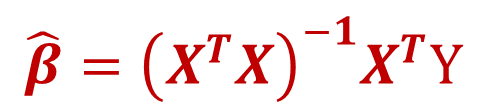
</div>

In [188]:
#Calcul Manuel
from scipy.linalg import inv
term1=inv(X_tr.T.dot(X_tr))
term2=X_tr.T.dot(y_train)
beta=term1.dot(term2)
print(beta)

[[53.94844202]
 [-0.3443307 ]]


In [74]:
#Calcul avec la méthode pinv de linalg
pinv = np.linalg.pinv(X_tr)
beta = pinv.dot(y_train)
print(beta)

[[53.94844202]
 [-0.3443307 ]]


In [196]:
#Calcul avec la méthode lstsq de linalg
beta = np.linalg.lstsq(X_tr, y_train, rcond=None)[0]
print(beta)

[[53.94844202]
 [-0.3443307 ]]


In [202]:
#Calcul avec la méthode polyfit de numpy
beta=(np.polyfit(x_train[:,0],y_train[:,0],1)).reshape(2,1)
print(beta)

[[53.94844202]
 [-0.3443307 ]]


## <font color="blue" size="3">c. Visualisation du modèle de régression</font>

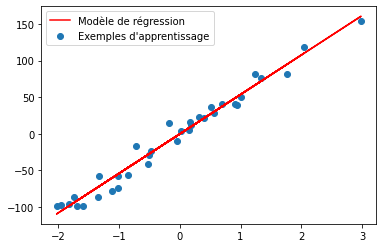

In [203]:
y_pred=modele(X_tr,beta)
plt.scatter(x_train,y_train,label="Exemples d'apprentissage")
plt.plot(x_train,y_pred,c='r',label="Modèle de régression")
plt.legend()

# <font color="red" size="4"><b>6. Evaluation du modèle sur l'ensemble de test par la méthode d'analyse de la variance </font>

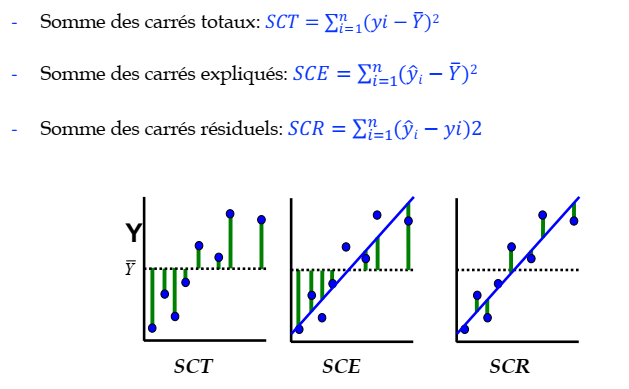

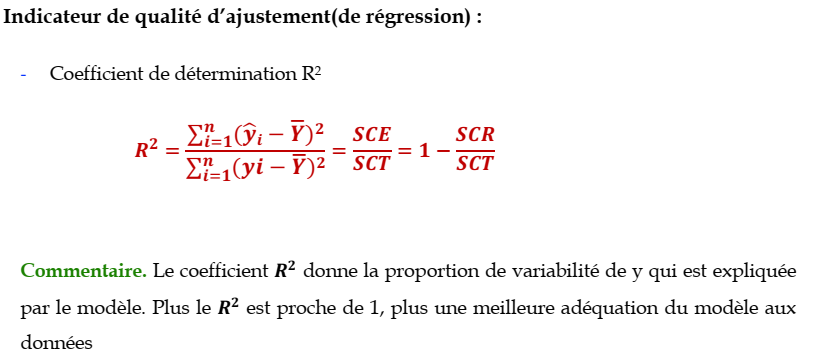

In [204]:
n_t=np.shape(x_test)[0]
vecteur_unitaire=np.ones((n_t,1))

X_te=np.hstack((x_test,vecteur_unitaire))

print(X_te.shape)


(15, 2)


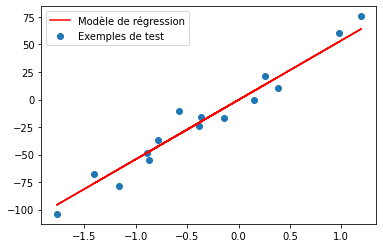

In [205]:
y_pred_t=modele(X_te,beta)
plt.scatter(x_test,y_test,label="Exemples de test")
plt.plot(x_test,y_pred_t,c='r',label="Modèle de régression")
plt.legend()

In [206]:

def coefficient_determination(y,y_pr):
  SCT=((y-y.mean())**2).sum()
  SCR=((y_pr-y)**2).sum()

  return 1- (SCR/SCT)

coefficient_determination(y_test,y_pred_t)


0.958207059294328